In [208]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
import calendar

In [209]:
files = glob.glob('/content/*.csv')   # all CSVs in /content/

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print("total records:",len(df))

total records: 1861108


In [210]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


In [211]:
print(df.isnull().sum())
print("duplicate rows exist:",df.duplicated().sum())


date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64
duplicate rows exist: 94896


Data Cleaning

In [212]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
df

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,07-11-2025,Haryana,Yamuna Nagar,135002,4,6
1,07-11-2025,Haryana,Yamunanagar,135001,1,2
2,07-11-2025,Himachal Pradesh,Bilaspur,174004,2,2
3,07-11-2025,Himachal Pradesh,Bilaspur,174005,1,0
4,07-11-2025,Himachal Pradesh,Bilaspur,174013,3,1
...,...,...,...,...,...,...
1861103,29-12-2025,West Bengal,Uttar Dinajpur,733201,4,9
1861104,29-12-2025,West Bengal,Uttar Dinajpur,733213,0,1
1861105,29-12-2025,West Bengal,West Midnapore,721304,0,3
1861106,29-12-2025,West Bengal,West Midnapore,721451,2,0


In [213]:
df = df.dropna()

Fix state name inconsistencies

In [214]:
df["state"] = (
    df["state"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


Create a MASTER STATE MAPPING

In [215]:
state_mapping = {
    # West Bengal variations
    "west  bengal": "west bengal",
    "westbengal": "west bengal",
    "west bangal": "west bengal",
    "west bengli": "west bengal",
    "jammu & kashmir": "jammu and kashmir",
    "andaman and nicobar islands": "andaman and nicobar",
    "daman & diu": "dadra and nagar haveli and daman and diu",
    "dadra & nagar haveli": "dadra and nagar haveli and daman and diu",
    "dadra and nagar haveli": "dadra and nagar haveli and daman and diu",
    "pondicherry": "puducherry",
    "chhatisgarh": "chhattisgarh",
    "uttaranchal": "uttarakhand"

}


In [216]:
df["state"] = df["state"].replace(state_mapping)


REMOVE NON-STATE ENTRIES

In [217]:
valid_states = {
    "andhra pradesh","arunachal pradesh","assam","bihar","chhattisgarh",
    "goa","gujarat","haryana","himachal pradesh","jharkhand","karnataka",
    "kerala","madhya pradesh","maharashtra","manipur","meghalaya","mizoram",
    "nagaland","odisha","punjab","rajasthan","sikkim","tamil nadu",
    "telangana","tripura","uttar pradesh","uttarakhand","west bengal",
    "andaman and nicobar","chandigarh","dadra and nagar haveli and daman and diu",
    "delhi","jammu and kashmir","ladakh","lakshadweep","puducherry"
}
df = df[df["state"].isin(valid_states)]


VERIFY CLEANING SUCCESS

In [218]:
print("Unique Clean States:", df["state"].nunique())
print(sorted(df["state"].unique()))

Unique Clean States: 36
['andaman and nicobar', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra and nagar haveli and daman and diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh', 'uttarakhand', 'west bengal']


Now created a new column for differentiating states and union territories

In [219]:
states = {
    "andhra pradesh","arunachal pradesh","assam","bihar","chhattisgarh",
    "goa","gujarat","haryana","himachal pradesh","jharkhand","karnataka",
    "kerala","madhya pradesh","maharashtra","manipur","meghalaya","mizoram",
    "nagaland","odisha","punjab","rajasthan","sikkim","tamil nadu",
    "telangana","tripura","uttar pradesh","uttarakhand","west bengal"
}

union_territories = {
    "andaman and nicobar",
    "chandigarh",
    "dadra and nagar haveli and daman and diu",
    "delhi",
    "jammu and kashmir",
    "ladakh",
    "lakshadweep",
    "puducherry"
}


ADD A NEW COLUMN → region_type

In [220]:
def classify_region(state):
    if state in states:
        return "State"
    elif state in union_territories:
        return "Union Territory"
    else:
        return "Unknown"

df["region_type"] = df["state"].apply(classify_region)


In [221]:
df["region_type"].value_counts()


,count
region_type,
State,1807706
Union Territory,39287


In [222]:
#created the timedataset for creating the time graphs and this is the cleaning process dtataset creatioon i have done for timedata set creation.

df_time = df.copy()

df_time["date"] = pd.to_datetime(df_time["date"], errors="coerce")

# keep only valid dates
df_time = df_time[df_time["date"].notna()]

print("Records with valid dates:", len(df_time))



Records with valid dates: 910122


In [223]:
df_time["year"] = df_time["date"].dt.year
df_time["month"] = df_time["date"].dt.month


created seperate database for state and union territories

In [224]:

#for state only
df_states = df[df["region_type"] == "State"]

#for union territories
df_uts = df[df["region_type"] == "Union Territory"]


#groupby ordering for the region wise


In [225]:
region_time = df_time.groupby(
    ["year", "region_type"]
)["bio_age_17_"].sum().reset_index()

In [226]:
df_time["year"] = df_time["date"].dt.year
df_time["month"] = df_time["date"].dt.month


monthly_district["month_name"] = monthly_district["month"].apply(
    lambda x: calendar.month_abbr[x]
)


# Now Creating Region Wise Mapping

In [261]:
region_mapping = {
    # North
    "jammu and kashmir": "North",
    "ladakh": "North",
    "himachal pradesh": "North",
    "punjab": "North",
    "haryana": "North",
    "delhi": "North",
    "uttarakhand": "North",
    "uttar pradesh": "North",

    # South
    "tamil nadu": "South",
    "kerala": "South",
    "karnataka": "South",
    "andhra pradesh": "South",
    "telangana": "South",

    # West
    "rajasthan": "West",
    "gujarat": "West",
    "maharashtra": "West",
    "goa": "West",

    # East
    "west bengal": "East",
    "odisha": "East",
    "bihar": "East",
    "jharkhand": "East",

    # Central
    "madhya pradesh": "Central",
    "chhattisgarh": "Central",

    # North East
    "assam": "North-East",
    "arunachal pradesh": "North-East",
    "manipur": "North-East",
    "meghalaya": "North-East",
    "mizoram": "North-East",
    "nagaland": "North-East",
    "tripura": "North-East",

    # UT Islands
    "andaman and nicobar": "Islands",
    "lakshadweep": "Islands",
    "puducherry": "South"
}


In [265]:
df["india_region"] = df["state"].map(region_mapping)
df["india_region"].value_counts()


,count
india_region,
South,683868
East,337439
West,325787
North,312717
Central,102077
North-East,78288
Islands,1848


In [270]:
df.groupby("india_region")[["bio_age_5_17", "bio_age_17_"]].sum()


,bio_age_5_17,bio_age_17_
india_region,,
Central,4084672,4487833
East,5323859,6527521
Islands,13627,9507
North,9196331,7019300
North-East,1108141,839265
South,7335200,7130796
West,7074358,9411647


# Till now this things done
✔ Multi-file ingestion
✔ Column standardization
✔ State/UT normalization
✔ Invalid data handling
✔ Canonical geography
✔ Region separation (State vs UT)

#Now need to do (EDA)

In [227]:
df.describe()


,pincode,bio_age_5_17,bio_age_17_
count,1.846993e+06,1.846993e+06,1.846993e+06
mean,5.200448e+05,1.852169e+01,1.921092e+01
std,1.978610e+05,8.400823e+01,8.838098e+01
min,1.100010e+05,0.000000e+00,0.000000e+00
25%,3.900170e+05,1.000000e+00,1.000000e+00
50%,5.213440e+05,4.000000e+00,4.000000e+00
75%,6.855540e+05,1.100000e+01,1.000000e+01
max,8.554560e+05,8.002000e+03,7.625000e+03


In [228]:
df["region_type"].value_counts()

df["region_type"].value_counts(normalize=True) * 100


,proportion
region_type,
State,97.872921
Union Territory,2.127079


In [229]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].isnull().sum()


np.int64(936871)

Biometric Usage data

In [230]:
age_group_totals = df[["bio_age_5_17", "bio_age_17_"]].sum()
print(age_group_totals)
(age_group_totals / age_group_totals.sum()) * 100



bio_age_5_17    34209438
bio_age_17_     35482426
dtype: int64


,0
bio_age_5_17,49.086703
bio_age_17_,50.913297


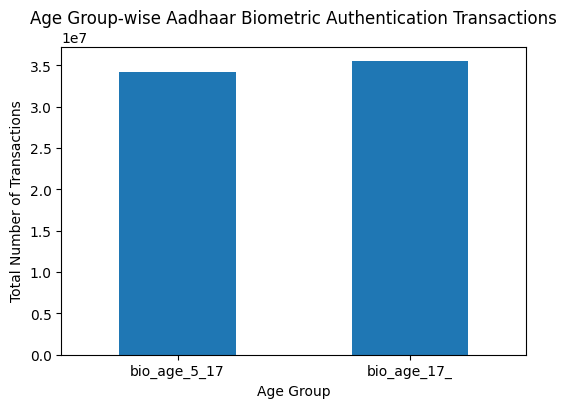

In [231]:
age_group_totals.plot(kind="bar", figsize=(6,4))
plt.title("Age Group-wise Aadhaar Biometric Authentication Transactions")
plt.xlabel("Age Group")
plt.ylabel("Total Number of Transactions")
plt.xticks(rotation=0)
plt.show()


State-wise Age Group Distribution

In [232]:
state_age = df.groupby("state")[["bio_age_5_17", "bio_age_17_"]].sum()
state_age = state_age.sort_values("bio_age_17_", ascending=False)
state_age.head(10)


,bio_age_5_17,bio_age_17_
state,,
maharashtra,3512712,5713427
uttar pradesh,6207105,3370630
madhya pradesh,3200117,2723654
bihar,2208141,2689446
tamil nadu,2227252,2470865
rajasthan,2066747,1928208
chhattisgarh,884555,1764179
gujarat,1460655,1735859
west bengal,1040512,1484107


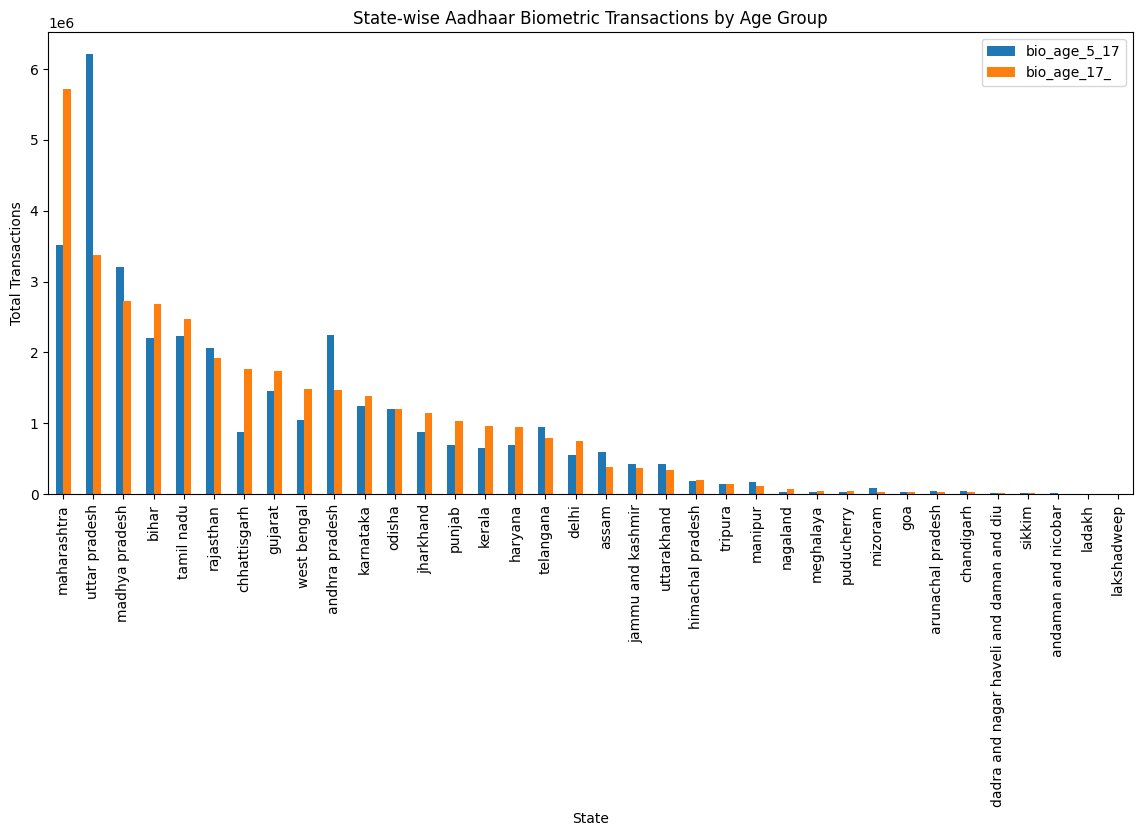

In [233]:
state_age.plot(kind="bar", figsize=(14,6))
plt.title("State-wise Aadhaar Biometric Transactions by Age Group")
plt.xlabel("State")
plt.ylabel("Total Transactions")
plt.xticks(rotation=90)
plt.show()


State vs Union Territory Comparison by Age Group

In [234]:
region_age_pattern = df.groupby("region_type")[["bio_age_5_17", "bio_age_17_"]].sum()

region_age_pattern["adult_share_percent"] = (
    region_age_pattern["bio_age_17_"] /
    (region_age_pattern["bio_age_5_17"] + region_age_pattern["bio_age_17_"])
) * 100

region_age_pattern


,bio_age_5_17,bio_age_17_,adult_share_percent
region_type,,,
State,33128052,34262011,50.841340
Union Territory,1081386,1220415,53.020005


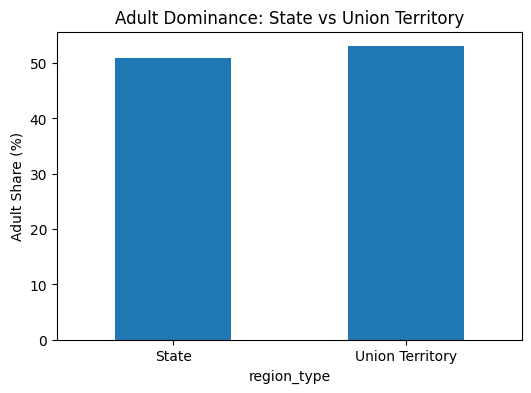

In [235]:
region_age_pattern["adult_share_percent"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Adult Dominance: State vs Union Territory")
plt.ylabel("Adult Share (%)")
plt.xticks(rotation=0)
plt.show()


District- and Pincode-level Analysis of Aadhaar Biometric Transactions

In [236]:
district_age_pattern = df.groupby("district")[["bio_age_5_17", "bio_age_17_"]].sum()

district_age_pattern["adult_share_percent"] = (
    district_age_pattern["bio_age_17_"] /
    (district_age_pattern["bio_age_5_17"] + district_age_pattern["bio_age_17_"])
) * 100

district_age_pattern.sort_values("adult_share_percent", ascending=False).head(10)


,bio_age_5_17,bio_age_17_,adult_share_percent
district,,,
?,0,1,100.0
udhampur,0,1,100.0
nadia,0,7,100.0
South DumDum(M),0,6,100.0
South 24 parganas,0,5,100.0
Tiruvarur,0,3,100.0
Tiswadi,0,2,100.0
Anugal,0,4,100.0
Salumbar,0,1,100.0


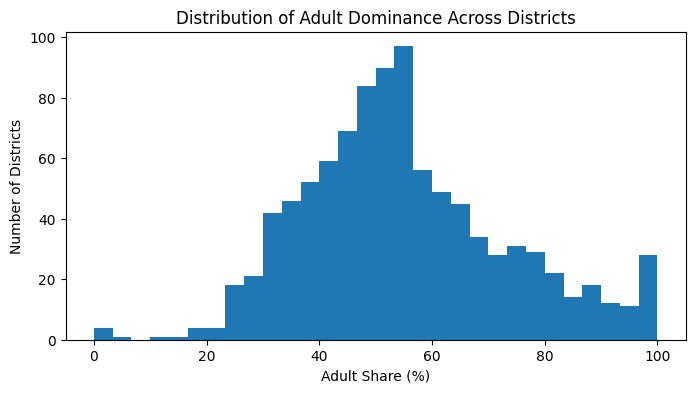

In [237]:
district_age_pattern["adult_share_percent"].plot(
    kind="hist",
    bins=30,
    figsize=(8,4)
)

plt.title("Distribution of Adult Dominance Across Districts")
plt.xlabel("Adult Share (%)")
plt.ylabel("Number of Districts")
plt.show()


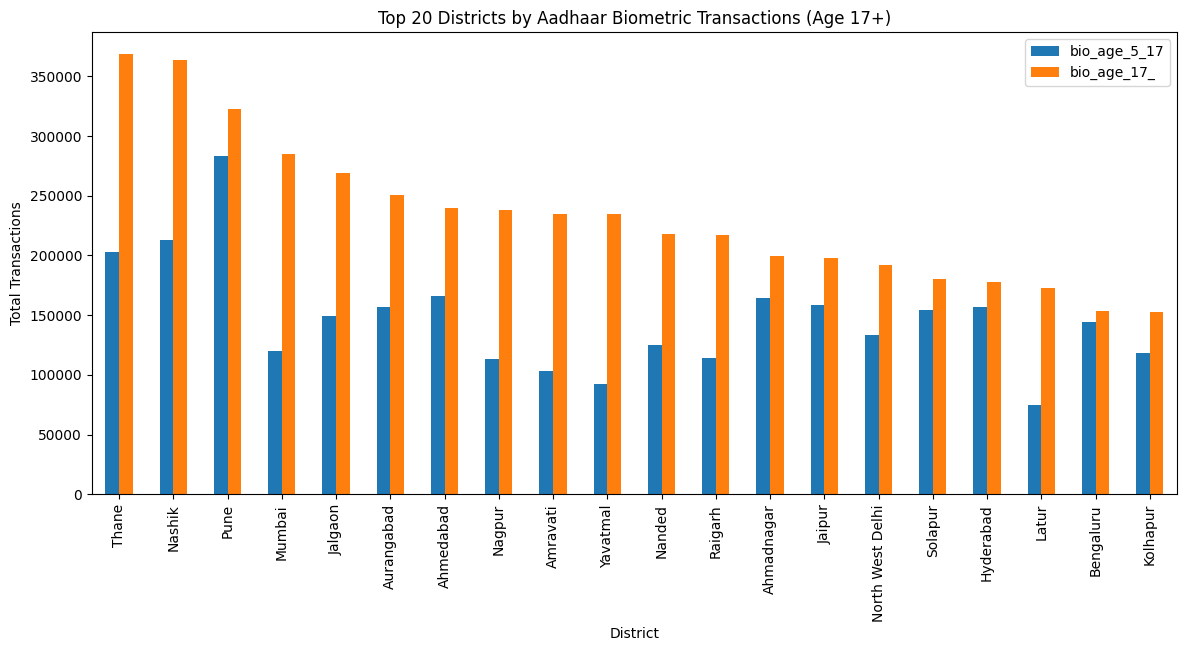

In [238]:
district_bio = df.groupby("district")[["bio_age_5_17", "bio_age_17_" ]].sum()
district_bio = district_bio.sort_values("bio_age_17_", ascending=False)
district_bio.head(20).plot(kind="bar", figsize=(14,6))
plt.title("Top 20 Districts by Aadhaar Biometric Transactions (Age 17+)")
plt.xlabel("District")
plt.ylabel("Total Transactions")
plt.xticks(rotation=90)
plt.show()

proportion of total biometric transactions, highlighting pronounced regional concentration.

In [239]:
top20_share = (
    district_bio.head(20)["bio_age_17_"].sum()
    / district_bio["bio_age_17_"].sum()
) * 100

top20_share


np.float64(13.145654133119308)

Pincode-level Concentration Analysis

In [240]:
pincode_bio = df.groupby("pincode")[["bio_age_5_17", "bio_age_17_"]].sum()
pincode_bio = pincode_bio.sort_values("bio_age_17_", ascending=False)
pincode_bio.head(10)


,bio_age_5_17,bio_age_17_
pincode,,
431001,27835,54661
110094,31858,46907
110086,26574,39616
110053,22766,36544
110059,24328,32736
421302,17948,32031
244001,45240,31883
423203,28502,29968
247001,31809,29608


Top Pincodes

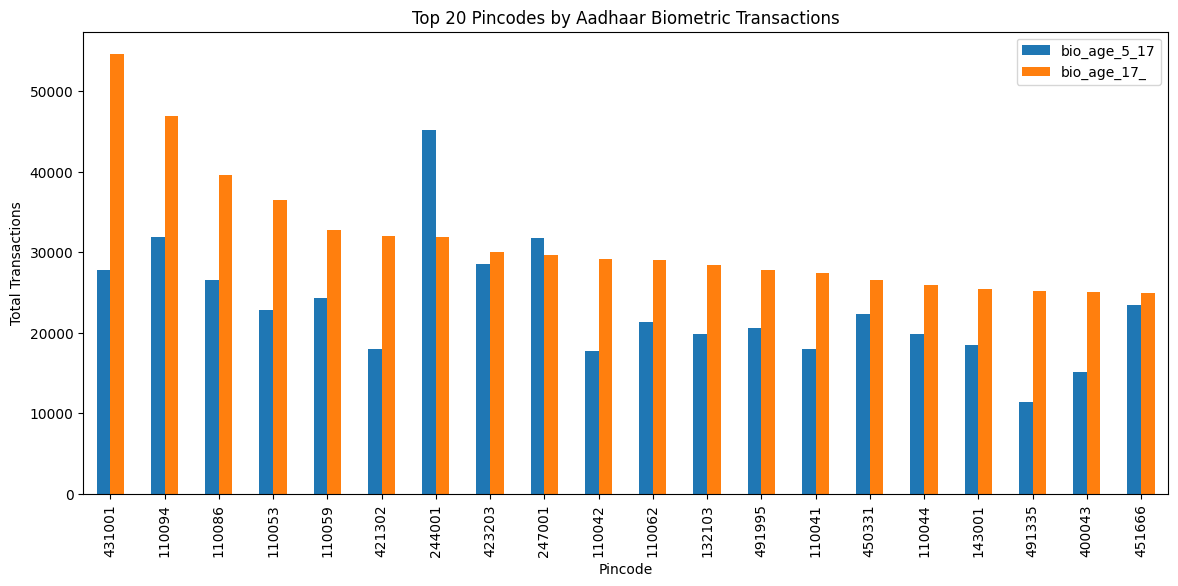

In [241]:
pincode_bio.head(20).plot(kind="bar", figsize=(14,6))
plt.title("Top 20 Pincodes by Aadhaar Biometric Transactions")
plt.xlabel("Pincode")
plt.ylabel("Total Transactions")
plt.xticks(rotation=90)
plt.show()


IDENTIFY & LABEL TRENDS

Trend Summary Table

In [242]:
trend_summary = pd.DataFrame({
    "Trend": [
        "Adult-dominant biometric usage",
        "High concentration in few states",
        "Transaction clustering in few districts",
        "Extreme concentration at pincode level"
    ]
})

trend_summary


,Trend
0,Adult-dominant biometric usage
1,High concentration in few states
2,Transaction clustering in few districts
3,Extreme concentration at pincode level


Pattern Discoveries


Pattern 1 — Concentration pattern

Few districts → most transactions
Few pincodes → majority within districts

In [243]:
district_bio["share"] = (
    district_bio["bio_age_17_"] /
    district_bio["bio_age_17_"].sum()
) * 100

district_bio.head(10)


,bio_age_5_17,bio_age_17_,share
district,,,
Thane,202896,368377,1.038196
Nashik,213100,363506,1.024468
Pune,283480,322282,0.908286
Mumbai,119615,284744,0.802493
Jalgaon,148853,268531,0.756800
Aurangabad,156879,250924,0.707178
Ahmedabad,165891,239599,0.675261
Nagpur,112851,238072,0.670958
Amravati,103569,234714,0.661494


Pattern 2 — Consistent age pattern

State-level age dominance

In [244]:
#In this the ratio is less than 80% so Adult biometric usage is less.


state_age_pattern = df.groupby("state")[["bio_age_5_17", "bio_age_17_"]].sum()

state_age_pattern["adult_dominance_ratio"] = (
    state_age_pattern["bio_age_17_"] /
    (state_age_pattern["bio_age_5_17"] + state_age_pattern["bio_age_17_"])
) * 100

state_age_pattern.sort_values("adult_dominance_ratio", ascending=False).head(10)


,bio_age_5_17,bio_age_17_,adult_dominance_ratio
state,,,
nagaland,32561,77032,70.289161
chhattisgarh,884555,1764179,66.604612
dadra and nagar haveli and daman and diu,12147,20358,62.630365
maharashtra,3512712,5713427,61.926522
puducherry,27046,42862,61.312010
punjab,700157,1039514,59.753482
kerala,647939,961791,59.748591
west bengal,1040512,1484107,58.785385
meghalaya,36531,51095,58.310319


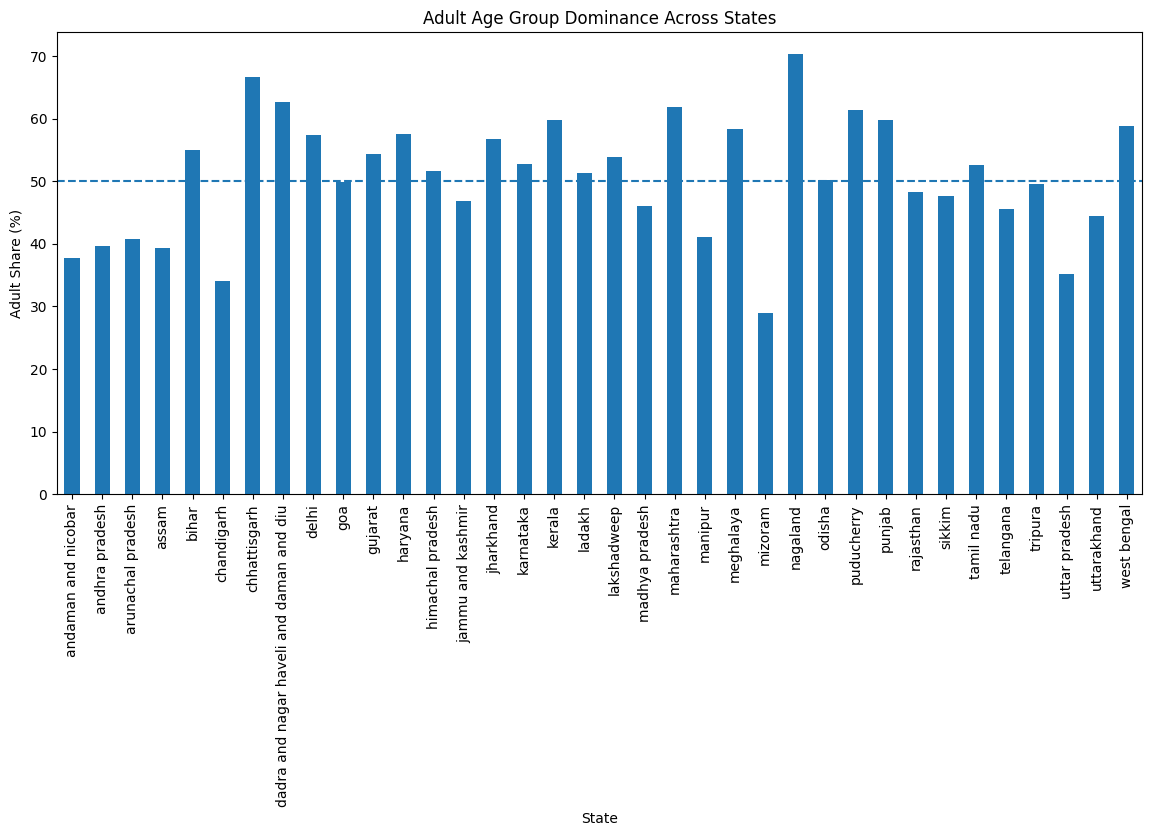

In [245]:
state_age_pattern["adult_dominance_ratio"].plot(
    kind="bar",
    figsize=(14,6)
)

plt.axhline(50, linestyle="--")
plt.title("Adult Age Group Dominance Across States")
plt.xlabel("State")
plt.ylabel("Adult Share (%)")
plt.xticks(rotation=90)
plt.show()


ANOMALY DETECTION

Combining both age groups into one indicator.

In [246]:
df["total_biometric"] = df["bio_age_5_17"] + df["bio_age_17_"]
df["total_biometric"]

,total_biometric
0,10
1,3
2,4
3,1
4,4
...,...
1861103,13
1861104,1
1861105,3
1861106,2


DISTRICT-LEVEL ANOMALIES

In [247]:
district_anomaly = (
    df.groupby("district")["total_biometric"]
    .sum()
    .sort_values(ascending=False)
)
top10_districts = district_anomaly.head(10)
top10_districts


,total_biometric
district,
Pune,605762
Nashik,576606
Thane,571273
Jalgaon,417384
Aurangabad,407803
Ahmedabad,405490
Mumbai,404359
Ahmadnagar,363561
Jaipur,355884


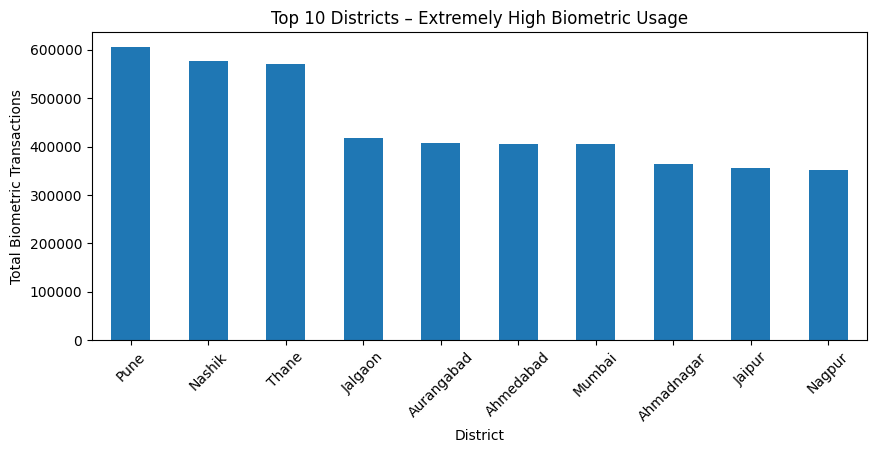

In [248]:
top10_districts.plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Districts – Extremely High Biometric Usage")
plt.xlabel("District")
plt.ylabel("Total Biometric Transactions")
plt.xticks(rotation=45)
plt.show()

#Possible service hubs, migration centers, welfare clusters, or overload risk zones.

BOTTOM 10 LOW-USAGE DISTRICTS

In [249]:
bottom10_districts = district_anomaly.tail(10)
bottom10_districts


,total_biometric
district,
Salumbar,1
Poonch,1
Mahoba *,1
Chandauli *,1
Bandipur,1
BALANGIR,1
Auraiya *,1
east midnapore,1
udhampur,1


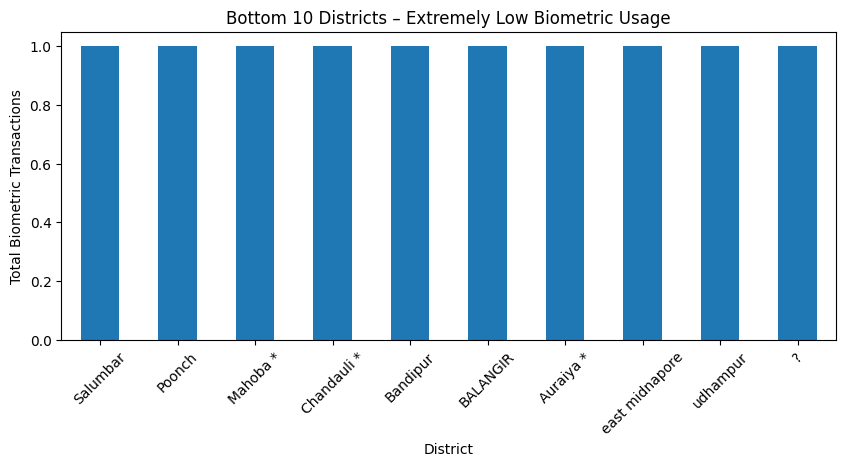

In [250]:
bottom10_districts.plot(kind="bar", figsize=(10,4))
plt.title("Bottom 10 Districts – Extremely Low Biometric Usage")
plt.xlabel("District")
plt.ylabel("Total Biometric Transactions")
plt.xticks(rotation=45)
plt.show()

#graph shows Potential digital exclusion, connectivity gaps, or under-utilization.

PINCODE-LEVEL ANOMALIES

In [251]:
pincode_anomaly = (
    df.groupby("pincode")["total_biometric"]
    .sum()
    .sort_values(ascending=False)
)
top10_pincode = pincode_anomaly.head(10)
top10_pincode


,total_biometric
pincode,
431001,82496
110094,78765
244001,77123
110086,66190
247001,61417
110053,59310
202001,59044
423203,58470
110059,57064


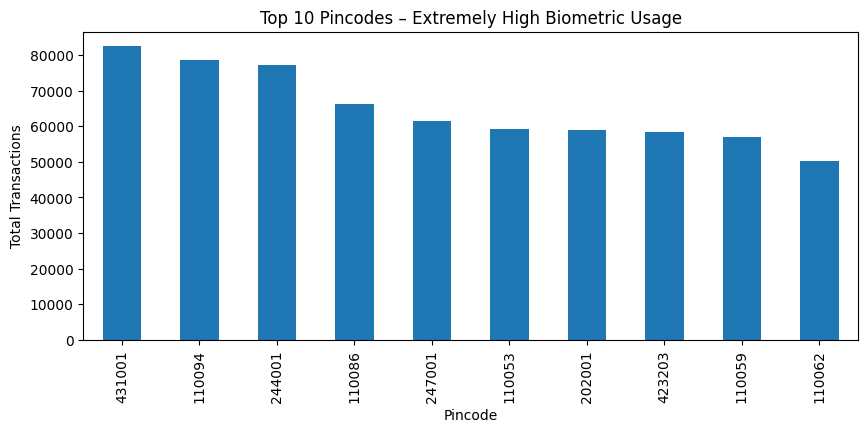

In [252]:
top10_pincode.plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Pincodes – Extremely High Biometric Usage")
plt.xlabel("Pincode")
plt.ylabel("Total Transactions")
plt.show()

#Very localized biometric dependency zones.

charts regarding time

In [253]:
#monthly trend charts

monthly_trend = df_time.groupby(["year", "month"])[
    ["bio_age_5_17", "bio_age_17_"]
].sum().reset_index()


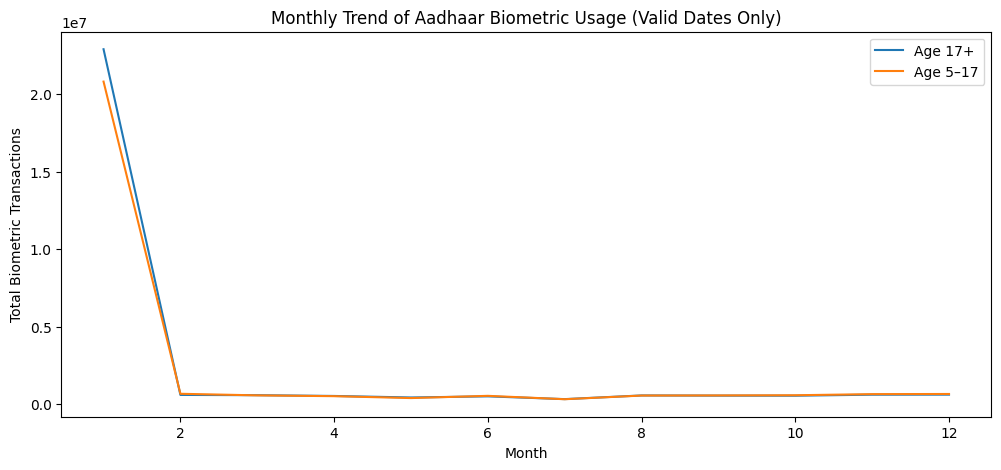

In [254]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["bio_age_17_"],
    label="Age 17+"
)

plt.plot(
    monthly_trend["month"],
    monthly_trend["bio_age_5_17"],
    label="Age 5–17"
)

plt.title("Monthly Trend of Aadhaar Biometric Usage (Valid Dates Only)")
plt.xlabel("Month")
plt.ylabel("Total Biometric Transactions")
plt.legend()
plt.show()


representing the biometric transactions change month-by-month

In [255]:
df_time["total_biometric"] = (
    df_time["bio_age_5_17"] + df_time["bio_age_17_"]
)

top10_districts = (
    df_time.groupby("district")["total_biometric"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

#monthly aggregating the top districts for the representation
monthly_district = (
    df_time[df_time["district"].isin(top10_districts)]
    .groupby(["district", "month"])["total_biometric"]
    .sum()
    .reset_index()
)



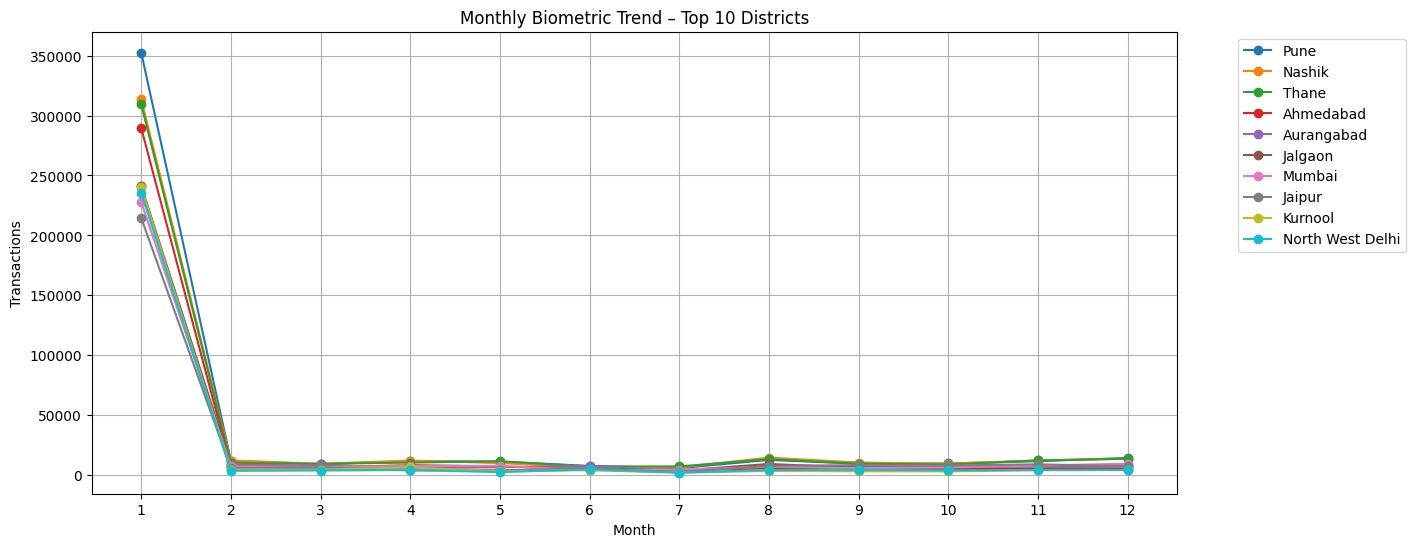

In [256]:
#merge graph representation for top 10 Districts
#in this graph it representing the biometric transactions change month-by-month for the top 10 districts.
plt.figure(figsize=(14,6))

for district in top10_districts:
    data = monthly_district[monthly_district["district"] == district]
    plt.plot(
        data["month"],
        data["total_biometric"],
        marker="o",
        label=district
    )

plt.title("Monthly Biometric Trend – Top 10 Districts")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(range(1,13))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


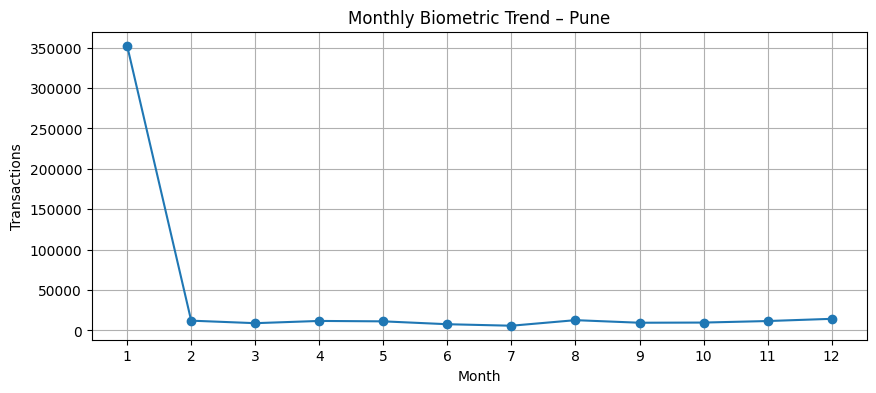

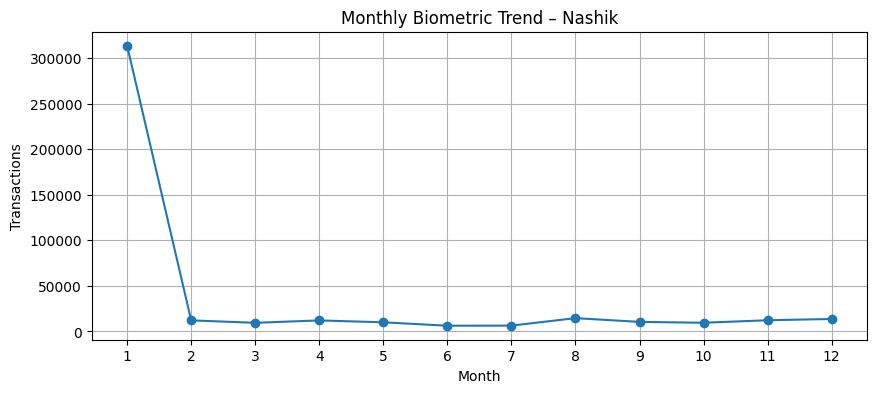

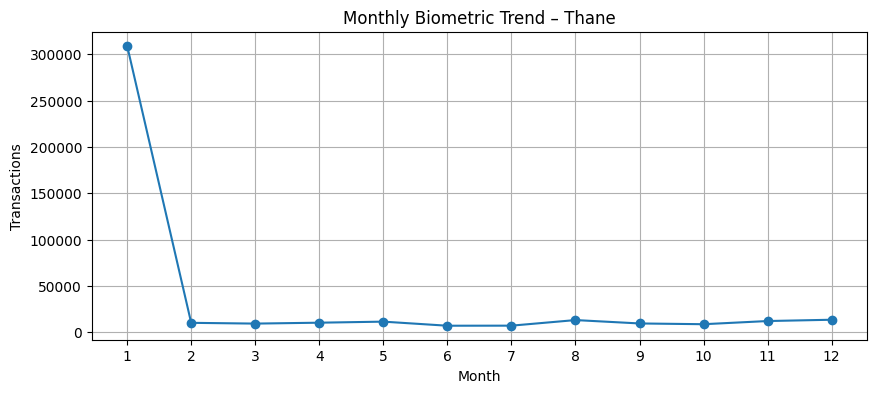

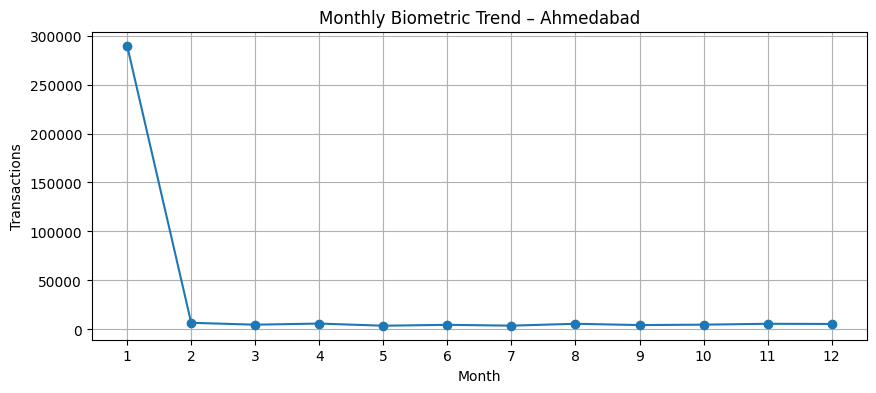

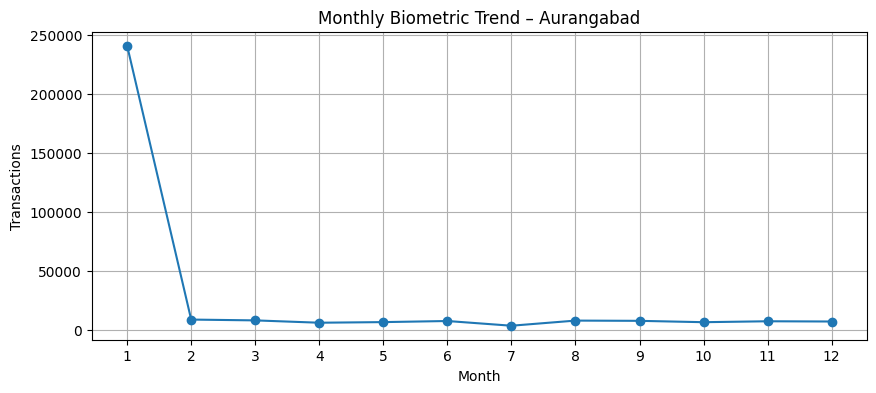

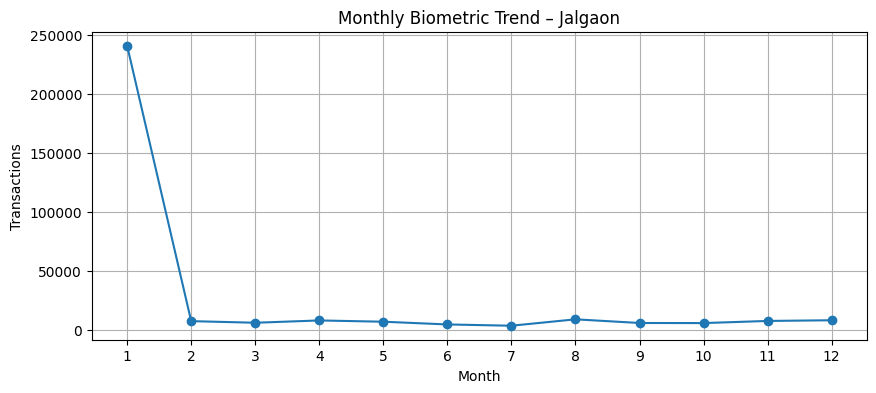

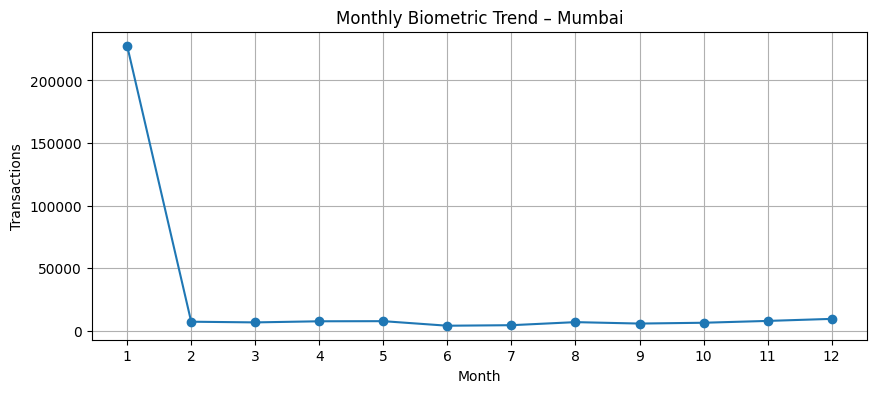

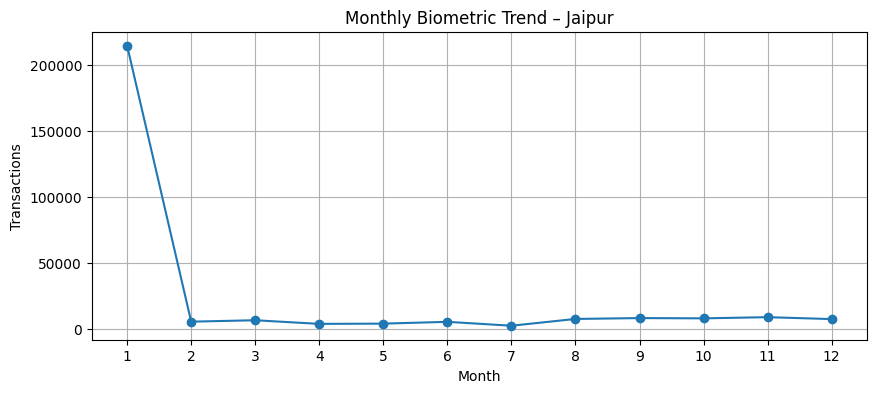

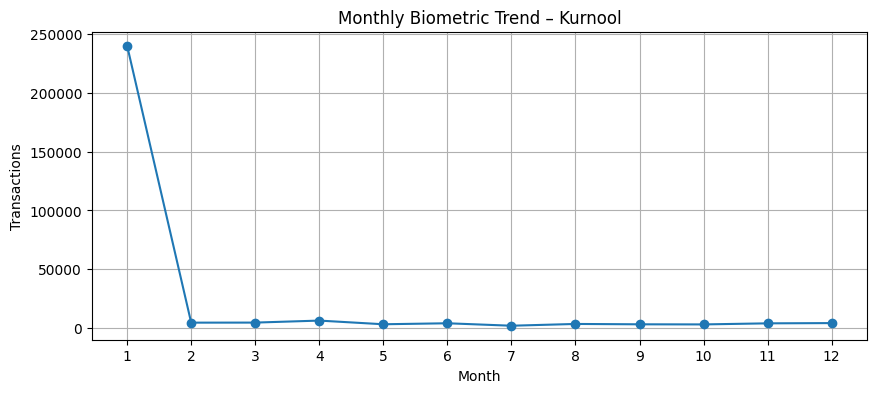

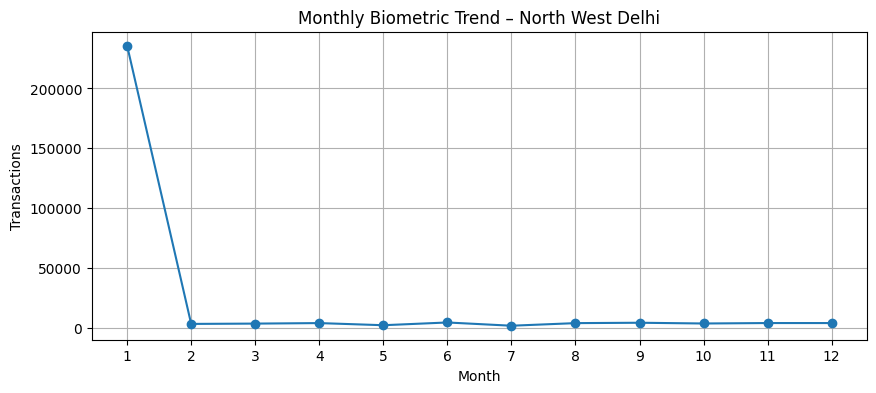

In [257]:
#these are the seperate graphs
#seperate graphs for biometric transactions change month-by-month for the top 10 districts.

for district in top10_districts:
    data = monthly_district[monthly_district["district"] == district]

    plt.figure(figsize=(10,4))
    plt.plot(
        data["month"],
        data["total_biometric"],
        marker="o"
    )

    plt.title(f"Monthly Biometric Trend – {district}")
    plt.xlabel("Month")
    plt.ylabel("Transactions")
    plt.xticks(range(1,13))
    plt.grid(True)
    plt.show()


HeatMap Representation

In [258]:
heatmap_data = monthly_district.pivot(
    index="district",
    columns="month",
    values="total_biometric"
)


# HeatMap Visulaisation
The heatmap visualizes month-wise biometric intensity across top districts.
 Darker regions indicate peak authentication periods, while lighter regions
 represent relatively lower activity. Recurrent dark zones across districts
 suggest system-wide seasonal behavior, whereas isolated spikes indicate localized anomalies.

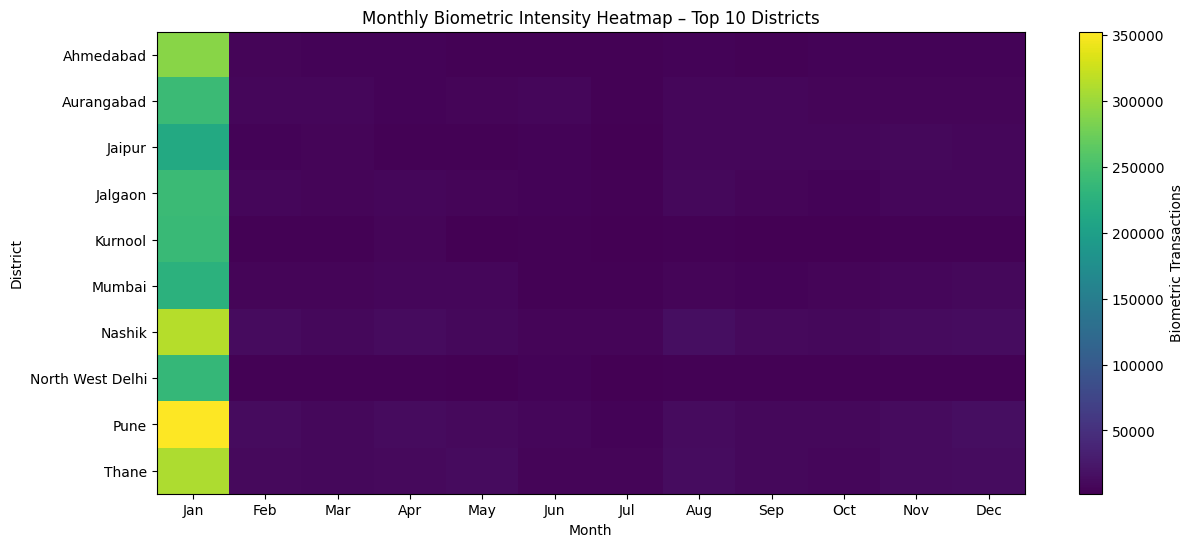

In [259]:
plt.figure(figsize=(14,6))
plt.imshow(heatmap_data, aspect="auto")

plt.colorbar(label="Biometric Transactions")
plt.title("Monthly Biometric Intensity Heatmap – Top 10 Districts")

plt.xticks(
    ticks=range(12),
    labels=[calendar.month_abbr[i] for i in range(1,13)]
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Month")
plt.ylabel("District")
plt.show()

REGION-WISE BIOMETRIC COMPARISON

In [272]:
region_age = df.groupby("india_region")[[
    "bio_age_5_17",
    "bio_age_17_"
]].sum()


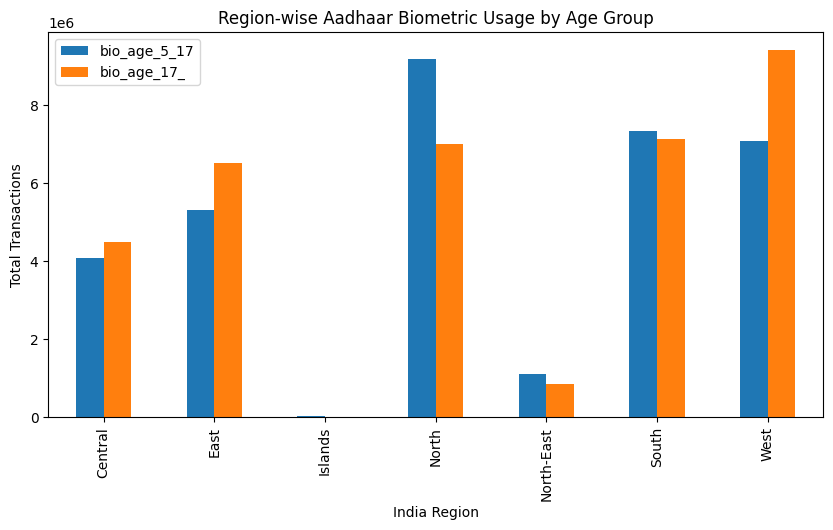

In [273]:
region_age.plot(kind="bar", figsize=(10,5))
plt.title("Region-wise Aadhaar Biometric Usage by Age Group")
plt.xlabel("India Region")
plt.ylabel("Total Transactions")
plt.show()


CHILD-FOCUSED ANALYSIS

In [274]:
df["child_share_percent"] = (
    df["bio_age_5_17"] /
    (df["bio_age_5_17"] + df["bio_age_17_"])
) * 100
child_region = df.groupby("india_region")["child_share_percent"].mean()
child_region


,child_share_percent
india_region,
Central,43.606988
East,42.011077
Islands,58.925032
North,53.604450
North-East,56.650053
South,48.477113
West,44.049833


This visualization compares Aadhaar biometric usage across major Indian regions.
 Adult biometric usage dominates in all regions; however, southern states show
 relatively higher child biometric activity compared to northern and
 north-eastern regions, indicating stronger integration of Aadhaar with education
 and child-focused services.

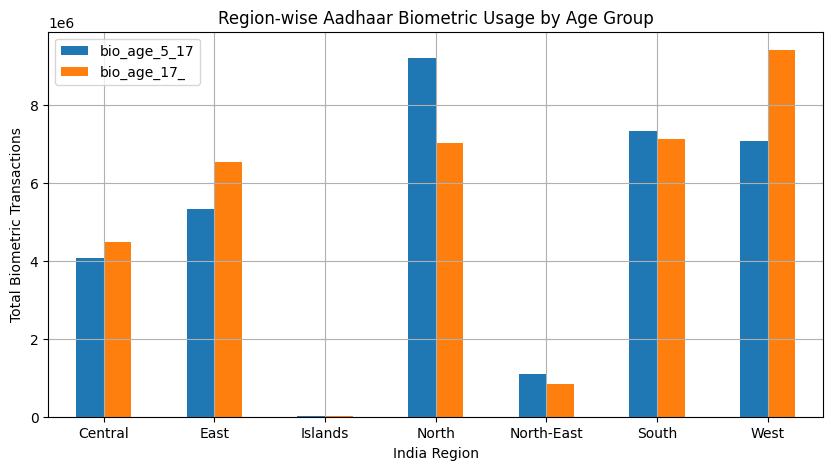

In [275]:

region_bio.plot(kind="bar", figsize=(10,5))
plt.title("Region-wise Aadhaar Biometric Usage by Age Group")
plt.xlabel("India Region")
plt.ylabel("Total Biometric Transactions")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


# #

In [278]:

#Calculate child and adult share (%)
df["total_biometric"] = df["bio_age_5_17"] + df["bio_age_17_"]
df["child_share_percent"] = (
    df["bio_age_5_17"] / df["total_biometric"]
) * 100

df["adult_share_percent"] = (
    df["bio_age_17_"] / df["total_biometric"]
) * 100


Region Wise Average Share

In [279]:
region_share = df.groupby("india_region")[[
    "child_share_percent",
    "adult_share_percent"
]].mean()

region_share


,child_share_percent,adult_share_percent
india_region,,
Central,43.606988,56.393012
East,42.011077,57.988923
Islands,58.925032,41.074968
North,53.604450,46.395550
North-East,56.650053,43.349947
South,48.477113,51.522887
West,44.049833,55.950167


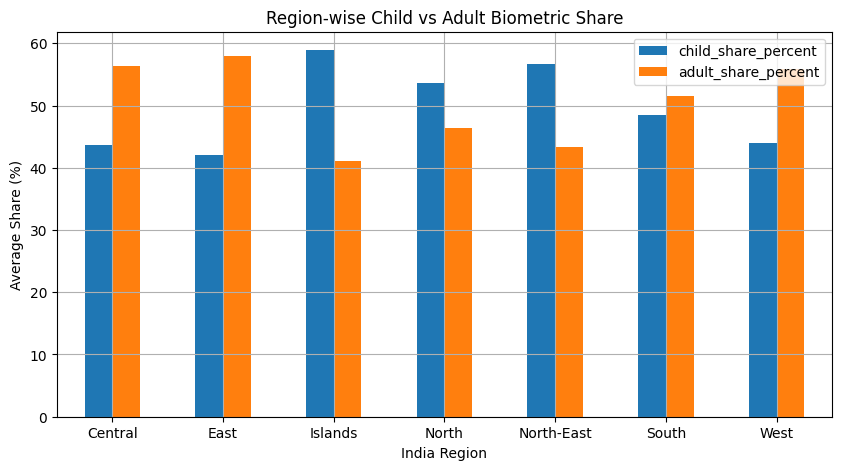

In [280]:
region_share.plot(kind="bar", figsize=(10,5))
plt.title("Region-wise Child vs Adult Biometric Share")
plt.xlabel("India Region")
plt.ylabel("Average Share (%)")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()
